# Análise Comparativa de Algoritmos de Agrupamento
## Estratificação Automática de Riscos Cibernéticos Organizacionais

**Autor:** Jônatas Fernandes  
**Metodologia:** CRISP-DM  
**Dataset:** Global Cybersecurity Threats 2015–2024 (Kaggle, 3.000 registros)

---
| Fase | Conteúdo |
|------|----------|
| 1 | Business Understanding |
| 2 | Data Understanding (EDA) |
| 3 | Data Preparation (limpeza · encoding · normalização · PCA) |
| 4 | Modeling (K-Means · DBSCAN · Híbrido) |
| 5 | Evaluation (métricas internas e externas) |
| 6 | Deployment (perfis · heatmap · classificador) |

## ⚙️ 0. Dependências

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

In [2]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, f1_score, confusion_matrix
)
from sklearn.neighbors import NearestNeighbors
from scipy.optimize import linear_sum_assignment

warnings.filterwarnings('ignore')
np.random.seed(42)

RISK_COLORS = {
    'Baixo':    '#2ecc71',
    'Médio':    '#f39c12',
    'Alto':     '#e74c3c',
    'Crítico':  '#8e44ad',
    'Anomalia': '#e74c3c'
}
print('Imports OK')

Imports OK


---
## 📋 FASE 1 — Business Understanding

**Problema:** Incidentes cibernéticos chegam sem prioridade consistente. A triagem manual é lenta e sujeita a erros.

**Objetivo:** Agrupar 3.000 incidentes reais em **4 perfis de risco** (Baixo / Médio / Alto / Crítico) e isolar **anomalias** de forma automática.

**Variáveis disponíveis no dataset:**

| Coluna | Tipo | Papel |
|--------|------|-------|
| `Financial Loss (in Million $)` | Contínua | Impacto financeiro |
| `Incident Resolution Time (in Hours)` | Contínua | MTTR operacional |
| `Number of Affected Users` | Contínua | Escala do incidente |
| `Attack Type` | Categórica (6 valores) | Natureza do ataque |
| `Target Industry` | Categórica (7 valores) | Criticidade do ativo |
| `Attack Source` | Categórica (4 valores) | Origem da ameaça |
| `Security Vulnerability Type` | Categórica (4 valores) | Vetor de exploração |
| `Defense Mechanism Used` | Categórica (5 valores) | Resposta aplicada |

---
## 📊 FASE 2 — Data Understanding
### 2.1 Carregamento do Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
CSV_PATH = '/content/Global_Cybersecurity_Threats_2015-2024.csv'

df_raw = pd.read_csv(CSV_PATH)
print(f'Shape: {df_raw.shape}')
display(df_raw.head())

Shape: (3000, 10)


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


### 2.2 Diagnóstico Geral

In [5]:
print('=== TIPOS E NULOS ===')
print(df_raw.dtypes)
print(f'\nNulos por coluna:\n{df_raw.isnull().sum()}')
print('\n=== ESTATÍSTICAS DESCRITIVAS ===')
display(df_raw.describe())

=== TIPOS E NULOS ===
Country                                 object
Year                                     int64
Attack Type                             object
Target Industry                         object
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                           object
Security Vulnerability Type             object
Defense Mechanism Used                  object
Incident Resolution Time (in Hours)      int64
dtype: object

Nulos por coluna:
Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

=== ESTATÍSTICAS DESCRITIVAS ===


,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


### 2.3 EDA — Variáveis Numéricas

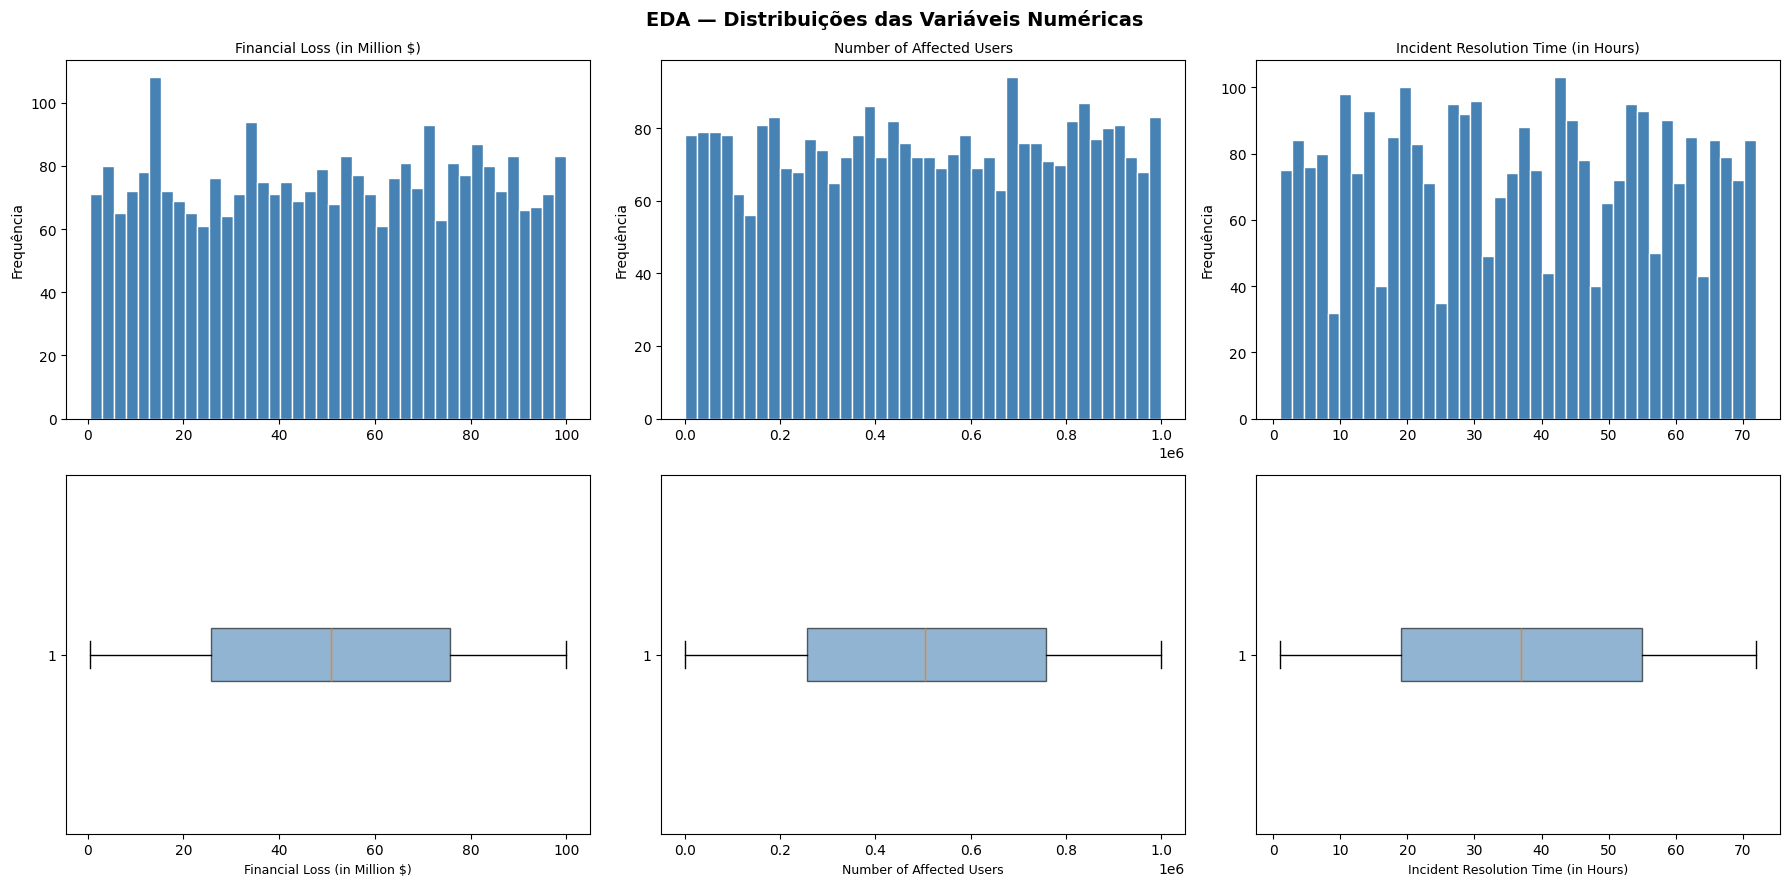

In [6]:
NUM_COLS_EDA = [
    'Financial Loss (in Million $)',
    'Number of Affected Users',
    'Incident Resolution Time (in Hours)'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('EDA — Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold')

for i, col in enumerate(NUM_COLS_EDA):
    axes[0, i].hist(df_raw[col], bins=40, color='steelblue', edgecolor='white')
    axes[0, i].set_title(col, fontsize=10)
    axes[0, i].set_ylabel('Frequência')
    axes[1, i].boxplot(df_raw[col], vert=False, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, i].set_xlabel(col, fontsize=9)

plt.tight_layout()
plt.savefig('eda_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 EDA — Variáveis Categóricas

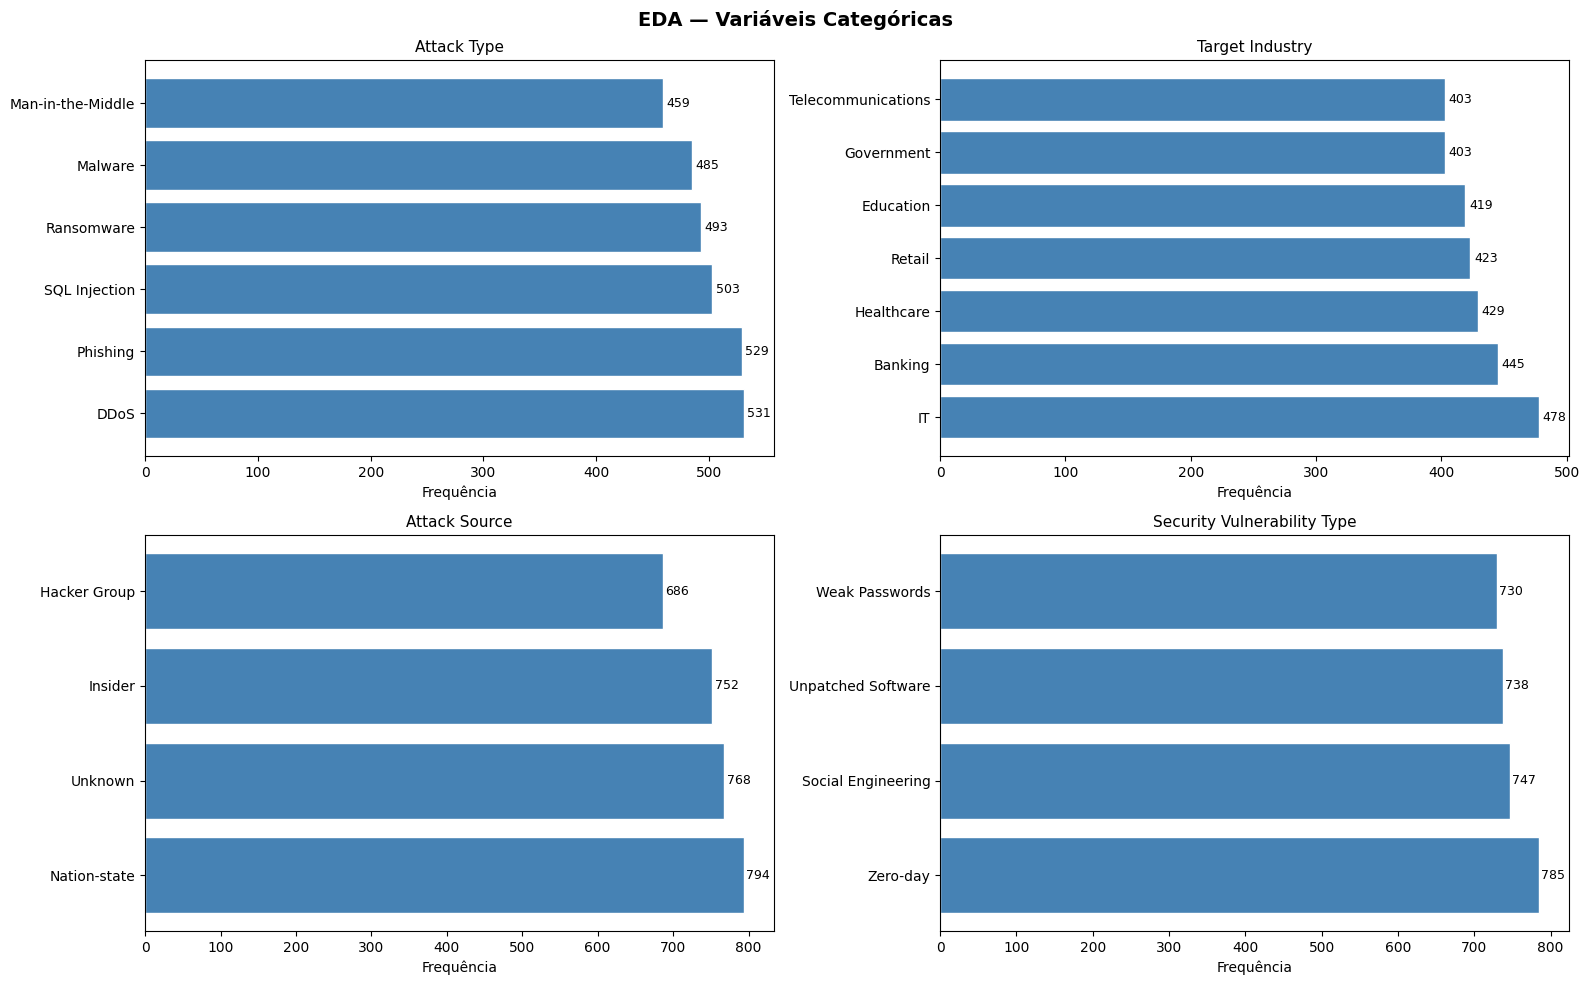

In [7]:
CAT_COLS_EDA = [
    'Attack Type', 'Target Industry',
    'Attack Source', 'Security Vulnerability Type'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('EDA — Variáveis Categóricas', fontsize=14, fontweight='bold')

for ax, col in zip(axes.ravel(), CAT_COLS_EDA):
    counts = df_raw[col].value_counts()
    bars = ax.barh(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Frequência')
    for bar, val in zip(bars, counts.values):
        ax.text(val + 3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 EDA — Impacto Financeiro por Tipo de Ataque e Indústria

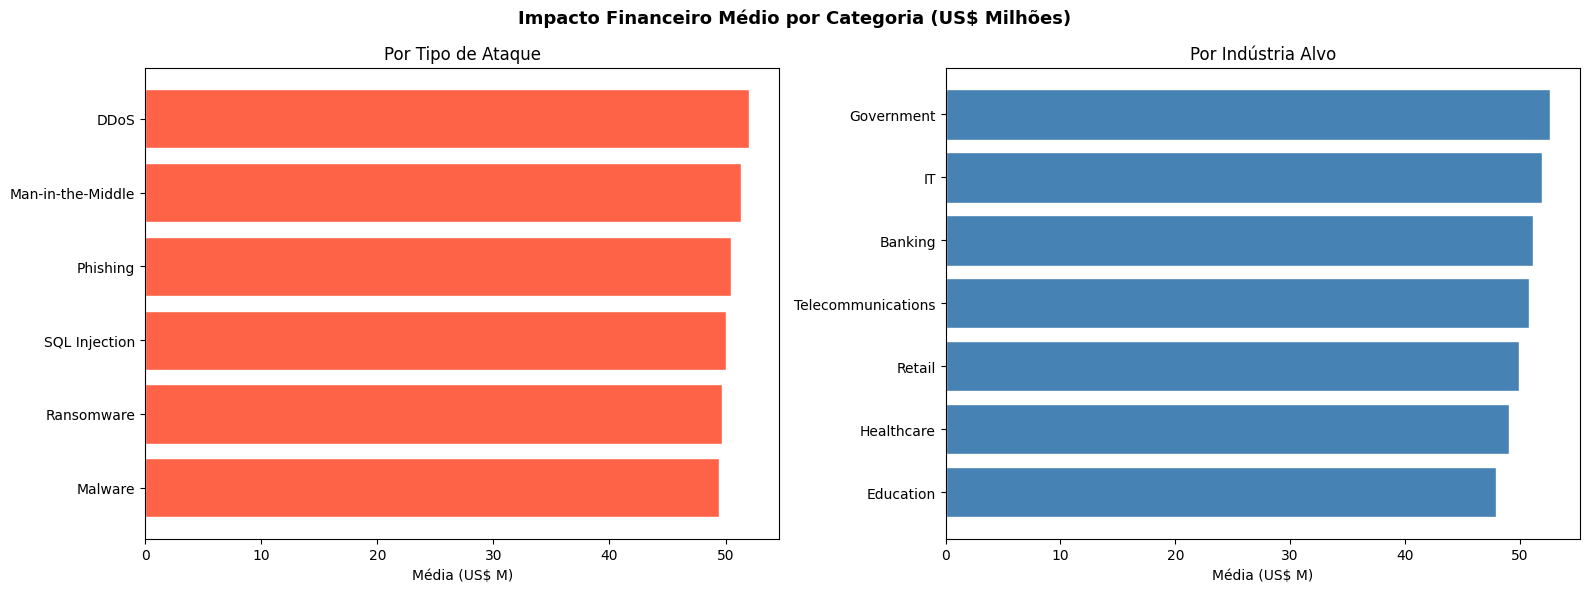

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Impacto Financeiro Médio por Categoria (US$ Milhões)',
             fontsize=13, fontweight='bold')

at_mean = df_raw.groupby('Attack Type')['Financial Loss (in Million $)'].mean().sort_values()
axes[0].barh(at_mean.index, at_mean.values, color='tomato', edgecolor='white')
axes[0].set_title('Por Tipo de Ataque'); axes[0].set_xlabel('Média (US$ M)')

ind_mean = df_raw.groupby('Target Industry')['Financial Loss (in Million $)'].mean().sort_values()
axes[1].barh(ind_mean.index, ind_mean.values, color='steelblue', edgecolor='white')
axes[1].set_title('Por Indústria Alvo'); axes[1].set_xlabel('Média (US$ M)')

plt.tight_layout()
plt.savefig('eda_impacto_financeiro.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔧 FASE 3 — Data Preparation
### 3.1 Engenharia de Features

In [9]:
df = df_raw.copy()

# Severity Score: proxy composto para CVSS
# Normaliza as 3 variáveis numéricas e combina com pesos
def minmax(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

df['Severity Score'] = (
    minmax(df['Financial Loss (in Million $)'])          * 0.50 +
    minmax(df['Incident Resolution Time (in Hours)'])    * 0.30 +
    minmax(df['Number of Affected Users'])               * 0.20
) * 10

# Pesos estratégicos baseados em risco intrínseco
source_weight = {'Nation-state': 1.5, 'Unknown': 1.2,
                 'Insider': 1.0, 'Hacker Group': 0.9}
vuln_weight   = {'Zero-day': 1.5, 'Social Engineering': 1.2,
                 'Unpatched Software': 1.0, 'Weak Passwords': 0.8}

df['Source_Weight'] = df['Attack Source'].map(source_weight).fillna(1.0)
df['Vuln_Weight']   = df['Security Vulnerability Type'].map(vuln_weight).fillna(1.0)
df['Risk_Score']    = df['Severity Score'] * df['Source_Weight'] * df['Vuln_Weight']

print('Features criadas: Severity Score, Source_Weight, Vuln_Weight, Risk_Score')
display(df[['Severity Score', 'Risk_Score']].describe().round(3))

Features criadas: Severity Score, Source_Weight, Vuln_Weight, Risk_Score


,Severity Score,Risk_Score
count,3000.000,3000.000
mean,5.021,6.595
std,1.778,3.162
min,0.444,0.639
25%,3.697,4.263
50%,5.048,6.113
75%,6.304,8.452
max,9.514,20.569


### 3.2 Label Encoding das Variáveis Categóricas

In [10]:
CAT_COLS = [
    'Attack Type', 'Target Industry', 'Attack Source',
    'Security Vulnerability Type', 'Defense Mechanism Used'
]

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Attack Type: {'DDoS': np.int64(0), 'Malware': np.int64(1), 'Man-in-the-Middle': np.int64(2), 'Phishing': np.int64(3), 'Ransomware': np.int64(4), 'SQL Injection': np.int64(5)}
Target Industry: {'Banking': np.int64(0), 'Education': np.int64(1), 'Government': np.int64(2), 'Healthcare': np.int64(3), 'IT': np.int64(4), 'Retail': np.int64(5), 'Telecommunications': np.int64(6)}
Attack Source: {'Hacker Group': np.int64(0), 'Insider': np.int64(1), 'Nation-state': np.int64(2), 'Unknown': np.int64(3)}
Security Vulnerability Type: {'Social Engineering': np.int64(0), 'Unpatched Software': np.int64(1), 'Weak Passwords': np.int64(2), 'Zero-day': np.int64(3)}
Defense Mechanism Used: {'AI-based Detection': np.int64(0), 'Antivirus': np.int64(1), 'Encryption': np.int64(2), 'Firewall': np.int64(3), 'VPN': np.int64(4)}


### 3.3 Normalização Z-score (StandardScaler)

In [11]:
NUM_COLS = [
    'Financial Loss (in Million $)',
    'Incident Resolution Time (in Hours)',
    'Number of Affected Users',
    'Severity Score',
    'Risk_Score'
]
ENC_COLS     = [c + '_enc' for c in CAT_COLS]
FEATURE_COLS = NUM_COLS + ENC_COLS

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURE_COLS])

print(f'Total de features: {len(FEATURE_COLS)}')
print(f'Média pós-escala (deve ser ≈0): {X_scaled.mean(axis=0).round(3)}')
print(f'Desvio-padrão (deve ser ≈1):    {X_scaled.std(axis=0).round(3)}')

Total de features: 10
Média pós-escala (deve ser ≈0): [ 0.  0.  0.  0. -0.  0.  0. -0. -0.  0.]
Desvio-padrão (deve ser ≈1):    [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 3.4 Redução de Dimensionalidade — PCA (2 Componentes)

Variância explicada — PC1: 26.52% | PC2: 11.36%
Total explicado pelos 2 componentes: 37.88%


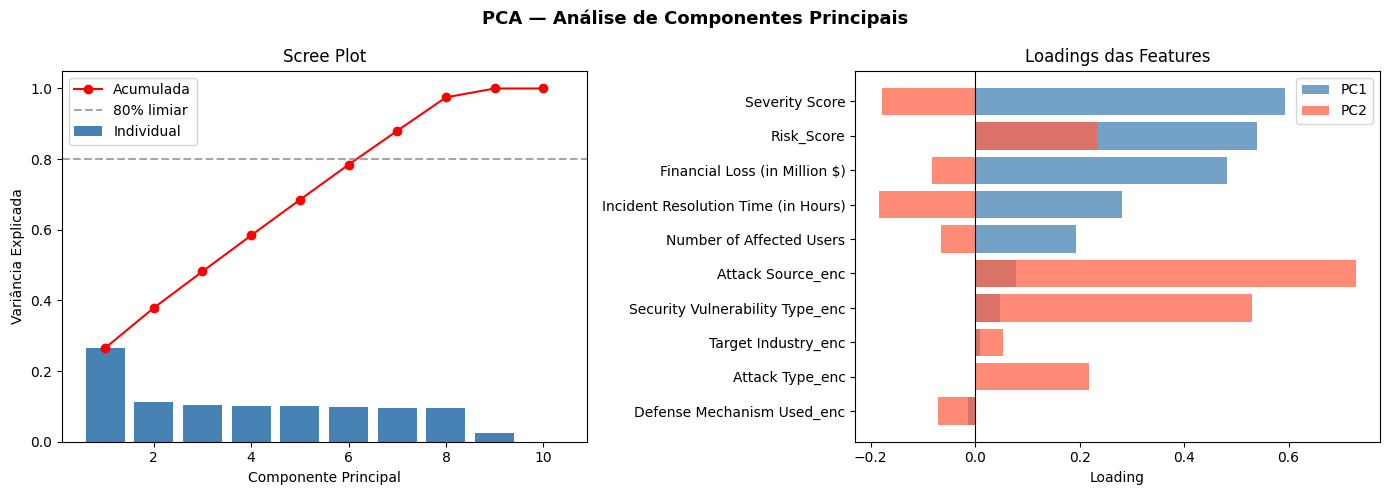

In [12]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f'Variância explicada — PC1: {var_exp[0]:.2%} | PC2: {var_exp[1]:.2%}')
print(f'Total explicado pelos 2 componentes: {var_exp.sum():.2%}')

# Scree Plot + Loadings
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA — Análise de Componentes Principais', fontsize=13, fontweight='bold')

axes[0].bar(range(1, len(cumvar)+1), pca_full.explained_variance_ratio_,
            color='steelblue', label='Individual')
axes[0].plot(range(1, len(cumvar)+1), cumvar, 'ro-', label='Acumulada')
axes[0].axhline(0.80, color='gray', linestyle='--', alpha=0.7, label='80% limiar')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada')
axes[0].set_title('Scree Plot'); axes[0].legend()

loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_COLS, columns=['PC1','PC2']
).sort_values('PC1')
axes[1].barh(loadings.index, loadings['PC1'], color='steelblue', label='PC1', alpha=0.75)
axes[1].barh(loadings.index, loadings['PC2'], color='tomato',    label='PC2', alpha=0.75)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Loadings das Features')
axes[1].set_xlabel('Loading'); axes[1].legend()

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

---
## 🤖 FASE 4 — Modeling
### 4.1 K-Means — Elbow Method + Silhouette + DBI

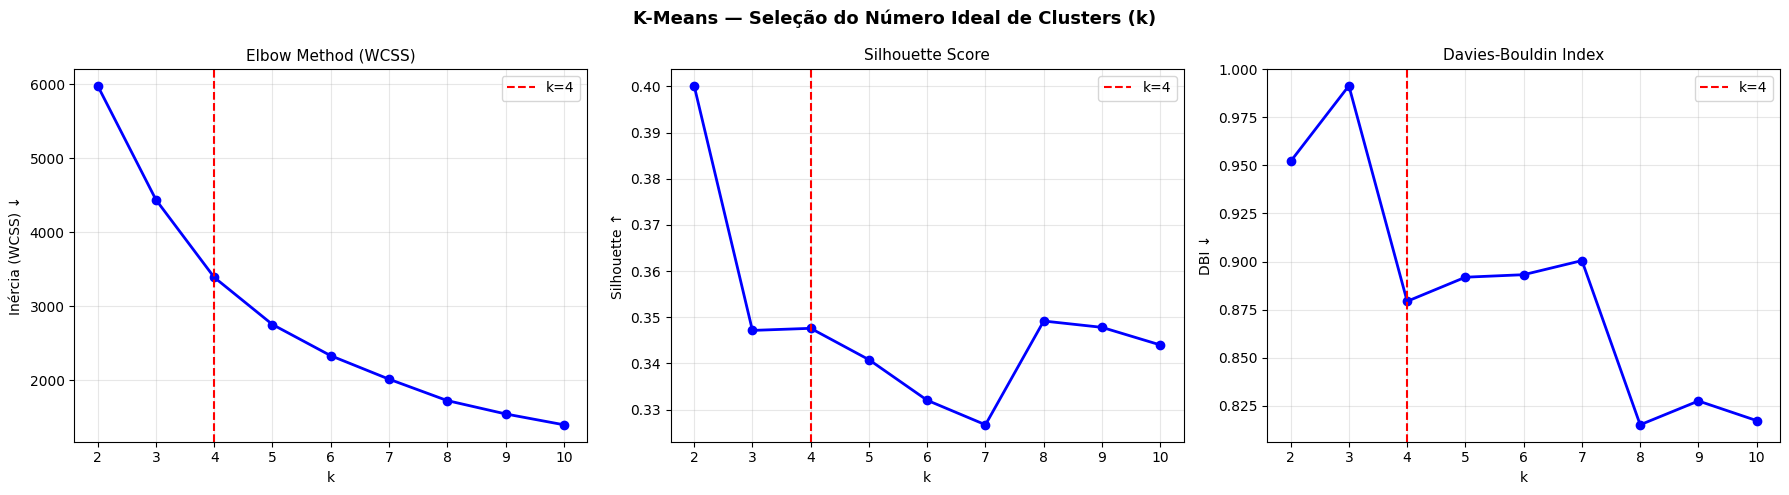

k ótimo definido: 4
Silhouette em k=4: 0.3476
DBI em k=4:        0.8793


In [13]:
K_RANGE   = range(2, 11)
wcss_vals = []
sil_vals  = []
db_vals   = []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbl = km.fit_predict(X_pca)
    wcss_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_pca, lbl))
    db_vals.append(davies_bouldin_score(X_pca, lbl))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('K-Means — Seleção do Número Ideal de Clusters (k)',
             fontsize=13, fontweight='bold')

configs = [
    (wcss_vals, 'Elbow Method (WCSS)',   'Inércia (WCSS) ↓'),
    (sil_vals,  'Silhouette Score',       'Silhouette ↑'),
    (db_vals,   'Davies-Bouldin Index',   'DBI ↓'),
]
for ax, (vals, title, ylabel) in zip(axes, configs):
    ax.plot(list(K_RANGE), vals, 'bo-', linewidth=2, markersize=6)
    ax.axvline(4, color='red', linestyle='--', linewidth=1.5, label='k=4')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('k'); ax.set_ylabel(ylabel)
    ax.set_xticks(list(K_RANGE))
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_selecao_k.png', dpi=150, bbox_inches='tight')
plt.show()

K_OPT = 4
print(f'k ótimo definido: {K_OPT}')
print(f'Silhouette em k=4: {sil_vals[K_OPT-2]:.4f}')
print(f'DBI em k=4:        {db_vals[K_OPT-2]:.4f}')

### 4.2 K-Means Final — Atribuição de Perfis de Risco

In [14]:
km_final  = KMeans(n_clusters=K_OPT, init='k-means++', n_init=20, random_state=42)
km_labels = km_final.fit_predict(X_pca)
df['KMeans_Cluster'] = km_labels

# Score de gravidade por cluster: combina perda financeira, MTTR e Risk_Score
gravity = df.groupby('KMeans_Cluster')[[
    'Financial Loss (in Million $)',
    'Incident Resolution Time (in Hours)',
    'Risk_Score'
]].mean()

g_norm = (gravity - gravity.min()) / (gravity.max() - gravity.min() + 1e-9)
gravity['score'] = (
    g_norm['Financial Loss (in Million $)']       * 0.40 +
    g_norm['Incident Resolution Time (in Hours)'] * 0.30 +
    g_norm['Risk_Score']                           * 0.30
)

rank     = gravity['score'].rank().astype(int)
label_km = {c: {1:'Baixo', 2:'Médio', 3:'Alto', 4:'Crítico'}[r] for c, r in rank.items()}

df['KMeans_Profile'] = df['KMeans_Cluster'].map(label_km)

print('Cluster → Perfil (K-Means):')
for c, lbl in sorted(label_km.items()):
    s = gravity.loc[c]
    print(f'  Cluster {c} → {lbl:8s} | Loss: {s["Financial Loss (in Million $)"]:.1f}M'
          f' | MTTR: {s["Incident Resolution Time (in Hours)"]:.1f}h'
          f' | Risk: {s["Risk_Score"]:.2f}')
print(f'\nContagem:\n{df["KMeans_Profile"].value_counts()}')

Cluster → Perfil (K-Means):
  Cluster 0 → Crítico  | Loss: 78.7M | MTTR: 46.4h | Risk: 10.67
  Cluster 1 → Baixo    | Loss: 21.9M | MTTR: 24.7h | Risk: 3.34
  Cluster 2 → Médio    | Loss: 45.1M | MTTR: 33.4h | Risk: 6.76
  Cluster 3 → Alto     | Loss: 59.6M | MTTR: 42.6h | Risk: 6.15

Contagem:
KMeans_Profile
Alto       788
Baixo      783
Médio      749
Crítico    680
Name: count, dtype: int64


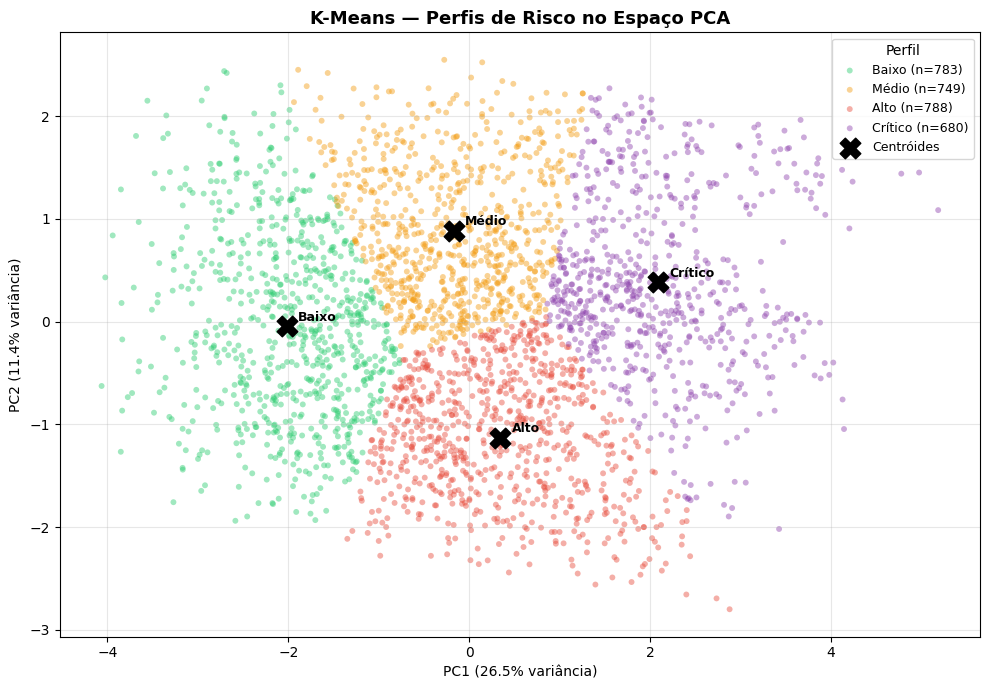

In [15]:
centroids = km_final.cluster_centers_

fig, ax = plt.subplots(figsize=(10, 7))
for profile, color in RISK_COLORS.items():
    if profile == 'Anomalia': continue
    mask = df['KMeans_Profile'] == profile
    ax.scatter(df.loc[mask,'PC1'], df.loc[mask,'PC2'],
               c=color, label=f'{profile} (n={mask.sum()})',
               alpha=0.45, s=18, edgecolors='none')

ax.scatter(centroids[:,0], centroids[:,1],
           c='black', marker='X', s=220, zorder=5, label='Centróides')
for i, (x, y) in enumerate(centroids):
    ax.annotate(label_km[i], (x, y), textcoords='offset points',
                xytext=(8, 4), fontsize=9, fontweight='bold')

ax.set_title('K-Means — Perfis de Risco no Espaço PCA', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} variância)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} variância)')
ax.legend(title='Perfil', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 DBSCAN — Sintonia de ε via k-Distância

### 4.3 DBSCAN — Varredura de ε

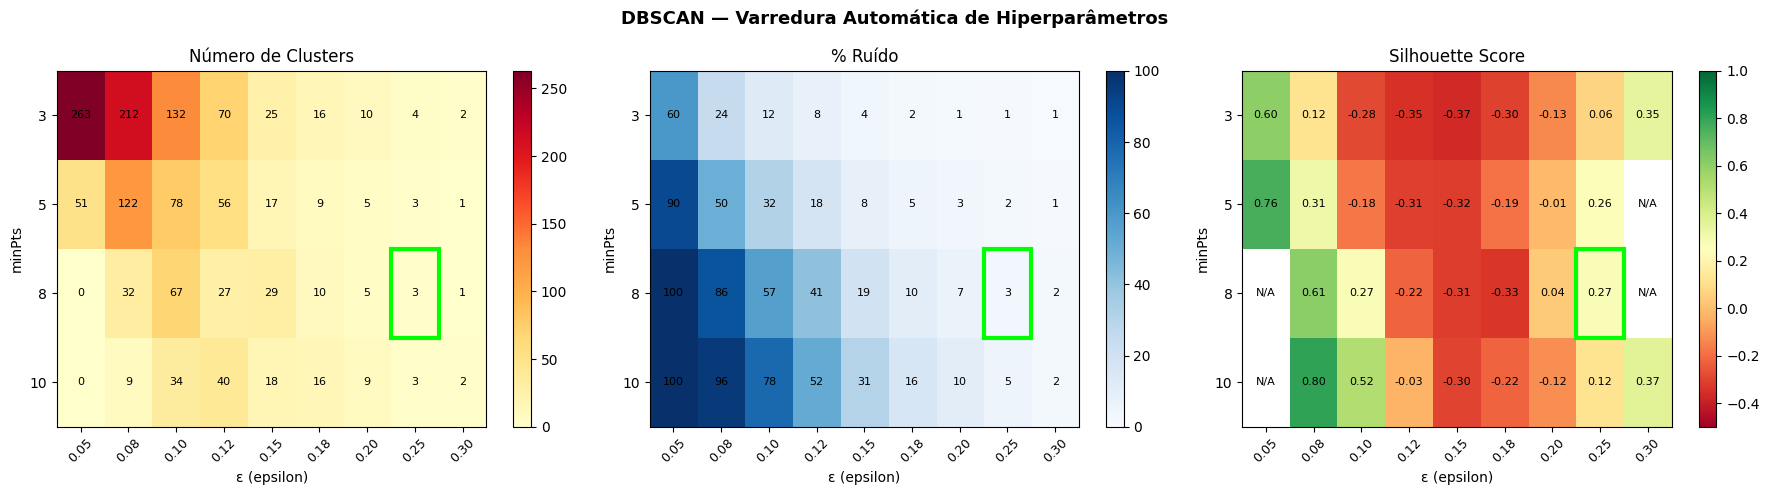


=== MELHOR CONFIGURAÇÃO AUTOMÁTICA ===
ε ótimo:        0.25
minPts ótimo:   8
Clusters:       3
Ruído:          92 (3.07%)
Silhouette:     0.2687
DBI:            0.6788
Métrica:        euclidean

=== TOP CONFIGURAÇÕES ===


,eps,minPts,clusters,noise,pct_noise,silhouette,dbi,score
30,0.25,8,3,92,3.0667,0.2687,0.6788,0.1638
29,0.25,5,3,52,1.7333,0.2633,0.6740,0.1604
31,0.25,10,3,152,5.0667,0.1180,0.5115,0.0362
28,0.25,3,4,34,1.1333,0.0631,0.5153,-0.0154
26,0.20,8,5,197,6.5667,0.0375,0.5915,-0.0578
25,0.20,5,5,96,3.2000,-0.0081,0.6556,-0.1097


In [31]:
EPS_RANGE  = [0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30]
MPTS_RANGE = [3, 5, 8, 10]

DISTANCE_METRIC = 'euclidean'

sweep = []

for eps in EPS_RANGE:
    for mpts in MPTS_RANGE:
        db = DBSCAN(
            eps=eps,
            min_samples=mpts,
            metric=DISTANCE_METRIC
        )

        lbl = db.fit_predict(X_pca)

        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise = int((lbl == -1).sum())
        pct_noise = (n_noise / len(lbl)) * 100
        mask = lbl != -1
        sil = np.nan
        dbi = np.nan

        if n_clusters >= 2 and mask.sum() > n_clusters:
            try:
                sil = silhouette_score(
                    X_pca[mask],
                    lbl[mask],
                    metric=DISTANCE_METRIC
                )
                dbi = davies_bouldin_score(
                    X_pca[mask],
                    lbl[mask]
                )
            except Exception:
                pass

        sweep.append({
            'eps': eps,
            'minPts': mpts,
            'clusters': n_clusters,
            'noise': n_noise,
            'pct_noise': pct_noise,
            'silhouette': sil,
            'dbi': dbi
        })

sweep_df = pd.DataFrame(sweep)

candidate_df = sweep_df[
    (sweep_df['clusters'] >= 3) &
    (sweep_df['clusters'] <= 6)
].copy()

candidate_df['score'] = (
    candidate_df['silhouette']
    - 0.15 * candidate_df['dbi']
    - 0.001 * candidate_df['pct_noise']
)

best_row = candidate_df.sort_values(
    'score',
    ascending=False
).iloc[0]

EPS_OPT = float(best_row['eps'])
MIN_PTS = int(best_row['minPts'])

dbscan = DBSCAN(
    eps=EPS_OPT,
    min_samples=MIN_PTS,
    metric=DISTANCE_METRIC
)

labels_db = dbscan.fit_predict(X_pca)

mask_final = labels_db != -1
FINAL_CLUSTERS = len(set(labels_db)) - (1 if -1 in labels_db else 0)
FINAL_NOISE = int((labels_db == -1).sum())
FINAL_NOISE_PCT = FINAL_NOISE / len(labels_db) * 100
FINAL_SIL = silhouette_score(
    X_pca[mask_final],
    labels_db[mask_final],
    metric=DISTANCE_METRIC
)
FINAL_DBI = davies_bouldin_score(
    X_pca[mask_final],
    labels_db[mask_final]
)

pivot_nc  = sweep_df.pivot(index='minPts', columns='eps', values='clusters')
pivot_nn  = sweep_df.pivot(index='minPts', columns='eps', values='pct_noise')
pivot_sil = sweep_df.pivot(index='minPts', columns='eps', values='silhouette')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'DBSCAN — Varredura Automática de Hiperparâmetros',
    fontsize=13,
    fontweight='bold'
)

tick_labels = [f'{v:.2f}' for v in pivot_nc.columns]
configs = [
    (axes[0], pivot_nc,  'YlOrRd', 'Número de Clusters', 'd',   0,   None),
    (axes[1], pivot_nn,  'Blues',  '% Ruído',            '.0f', 0,   100),
    (axes[2], pivot_sil, 'RdYlGn', 'Silhouette Score',   '.2f', -0.5, 1.0),
]

for ax, pivot, cmap, title, fmt, vmin, vmax in configs:
    vals = pivot.values.astype(float)
    im = ax.imshow(
        vals,
        aspect='auto',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(
        tick_labels,
        rotation=45,
        fontsize=9
    )

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('ε (epsilon)')
    ax.set_ylabel('minPts')
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

    # valores internos
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if np.isnan(v):
                txt = 'N/A'
            elif fmt == 'd':
                txt = str(int(v))
            else:
                txt = f'{v:{fmt}}'
            ax.text(
                j,
                i,
                txt,
                ha='center',
                va='center',
                fontsize=8
            )

opt_j = list(pivot_nc.columns).index(EPS_OPT)
opt_i = list(pivot_nc.index).index(MIN_PTS)

for ax in axes:
    ax.add_patch(
        plt.Rectangle(
            (opt_j - 0.5, opt_i - 0.5),
            1,
            1,
            fill=False,
            edgecolor='lime',
            linewidth=3
        )
    )

plt.tight_layout()
plt.savefig(
    'dbscan_sweep_heatmaps.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()


print('\n=== MELHOR CONFIGURAÇÃO ===')
print(f'ε ótimo:        {EPS_OPT}')
print(f'minPts ótimo:   {MIN_PTS}')
print(f'Clusters:       {FINAL_CLUSTERS}')
print(f'Ruído:          {FINAL_NOISE} ({FINAL_NOISE_PCT:.2f}%)')
print(f'Silhouette:     {FINAL_SIL:.4f}')
print(f'DBI:            {FINAL_DBI:.4f}')
print(f'Métrica:        {DISTANCE_METRIC}')

print('\n=== TOP CONFIGURAÇÕES ===')
display(
    candidate_df
    .sort_values('score', ascending=False)
    .head(10)
    .round(4)
)

### 4.4 DBSCAN Final — Clusters e Anomalias Isoladas

In [37]:
dbscan    = DBSCAN(eps=EPS_OPT, min_samples=MIN_PTS)
db_labels = dbscan.fit_predict(X_pca)
df['DBSCAN_Label'] = db_labels

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = int((db_labels == -1).sum())

print(f'Clusters formados:          {n_clusters_db}')
print(f'Anomalias isoladas (ruído): {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')

# Perfil das anomalias
anomaly_mask = db_labels == -1
if anomaly_mask.sum() > 0:
    print('\nTop vulnerabilidades nas anomalias:')
    print(df[anomaly_mask]['Security Vulnerability Type'].value_counts())
    print('\nTop origens das anomalias:')
    print(df[anomaly_mask]['Attack Source'].value_counts())
    print('\nEstatísticas financeiras das anomalias:')
    display(df[anomaly_mask][['Financial Loss (in Million $)',
                               'Incident Resolution Time (in Hours)',
                               'Risk_Score']].describe().round(2))


Clusters formados:          3
Anomalias isoladas (ruído): 92 (3.1%)

Top vulnerabilidades nas anomalias:
Security Vulnerability Type
Zero-day              40
Social Engineering    30
Unpatched Software    13
Weak Passwords         9
Name: count, dtype: int64

Top origens das anomalias:
Attack Source
Unknown         35
Hacker Group    24
Nation-state    19
Insider         14
Name: count, dtype: int64

Estatísticas financeiras das anomalias:


,Financial Loss (in Million $),Incident Resolution Time (in Hours),Risk_Score
count,92.00,92.00,92.00
mean,42.71,31.87,6.41
std,36.96,26.84,5.51
min,0.61,1.00,0.64
25%,10.30,7.75,1.72
50%,24.72,18.50,4.75
75%,84.53,61.00,10.23
max,98.09,72.00,20.57


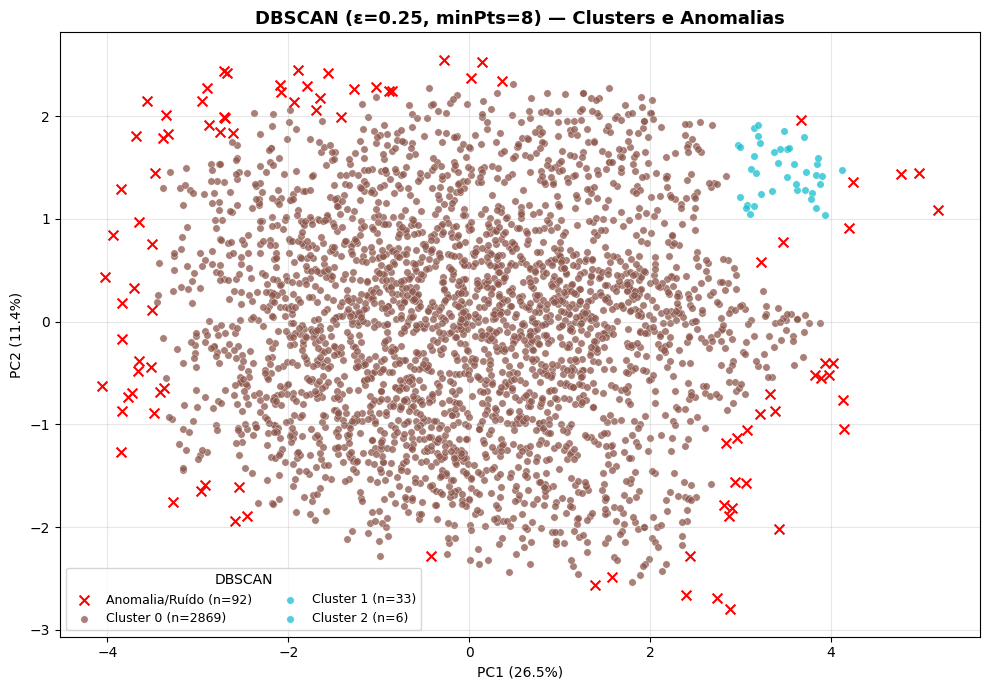

In [38]:
cmap2 = plt.cm.get_cmap('tab10', max(n_clusters_db, 1))

fig, ax = plt.subplots(figsize=(10, 7))
for i, lbl in enumerate(sorted(set(db_labels))):
    mask = db_labels == lbl
    if lbl == -1:
        ax.scatter(X_pca[mask,0], X_pca[mask,1],
                   c='red', marker='x', s=50, linewidths=1.5,
                   label=f'Anomalia/Ruído (n={mask.sum()})', zorder=5)
    else:
        ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=[cmap2(i % 10)],
        alpha=0.75,
        s=28,
        edgecolors='white',
        linewidths=0.3,
        label=f'Cluster {lbl} (n={mask.sum()})'
        )

ax.set_title(f'DBSCAN (ε={EPS_OPT}, minPts={MIN_PTS}) — Clusters e Anomalias',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1%})')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%})')
ax.legend(title='DBSCAN', fontsize=9, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Abordagem Híbrida — DBSCAN como Filtro + K-Means para Perfis

In [39]:
# Fase 1: Segregar anomalias
mask_clean   = db_labels != -1
mask_anomaly = db_labels == -1
X_clean      = X_pca[mask_clean]

print(f'Registros para K-Means (sem ruído): {X_clean.shape[0]}')
print(f'Anomalias segregadas:               {mask_anomaly.sum()}')

# Fase 2: K-Means sobre dados limpos
km_hyb     = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=42)
hyb_labels = km_hyb.fit_predict(X_clean)

# Fase 3: Mapear centróides por gravidade
df_clean = df[mask_clean].copy()
df_clean['Cluster_H'] = hyb_labels

gravity_h = df_clean.groupby('Cluster_H')[[
    'Financial Loss (in Million $)',
    'Incident Resolution Time (in Hours)',
    'Risk_Score'
]].mean()

gh_norm = (gravity_h - gravity_h.min()) / (gravity_h.max() - gravity_h.min() + 1e-9)
gravity_h['score'] = (
    gh_norm['Financial Loss (in Million $)']       * 0.40 +
    gh_norm['Incident Resolution Time (in Hours)'] * 0.30 +
    gh_norm['Risk_Score']                           * 0.30
)

rank_h    = gravity_h['score'].rank().astype(int)
label_hyb = {c: {1:'Baixo', 2:'Médio', 3:'Alto', 4:'Crítico'}[r]
             for c, r in rank_h.items()}

# Monta vetor de perfis final
hybrid_profiles   = np.full(len(df), 'Anomalia', dtype=object)
clean_indices     = np.where(mask_clean)[0]
for idx, cl in zip(clean_indices, hyb_labels):
    hybrid_profiles[idx] = label_hyb[cl]

df['Hybrid_Profile'] = hybrid_profiles

print('\nCluster → Perfil (Híbrido):')
for c, lbl in sorted(label_hyb.items()):
    s = gravity_h.loc[c]
    print(f'  Cluster {c} → {lbl:8s} | Loss: {s["Financial Loss (in Million $)"]:.1f}M'
          f' | MTTR: {s["Incident Resolution Time (in Hours)"]:.1f}h')
print(f'\nContagem:\n{pd.Series(hybrid_profiles).value_counts()}')

Registros para K-Means (sem ruído): 2908
Anomalias segregadas:               92

Cluster → Perfil (Híbrido):
  Cluster 0 → Alto     | Loss: 61.1M | MTTR: 42.9h
  Cluster 1 → Médio    | Loss: 44.3M | MTTR: 34.0h
  Cluster 2 → Baixo    | Loss: 23.1M | MTTR: 25.9h
  Cluster 3 → Crítico  | Loss: 77.9M | MTTR: 44.7h

Contagem:
Baixo       767
Alto        747
Médio       728
Crítico     666
Anomalia     92
Name: count, dtype: int64


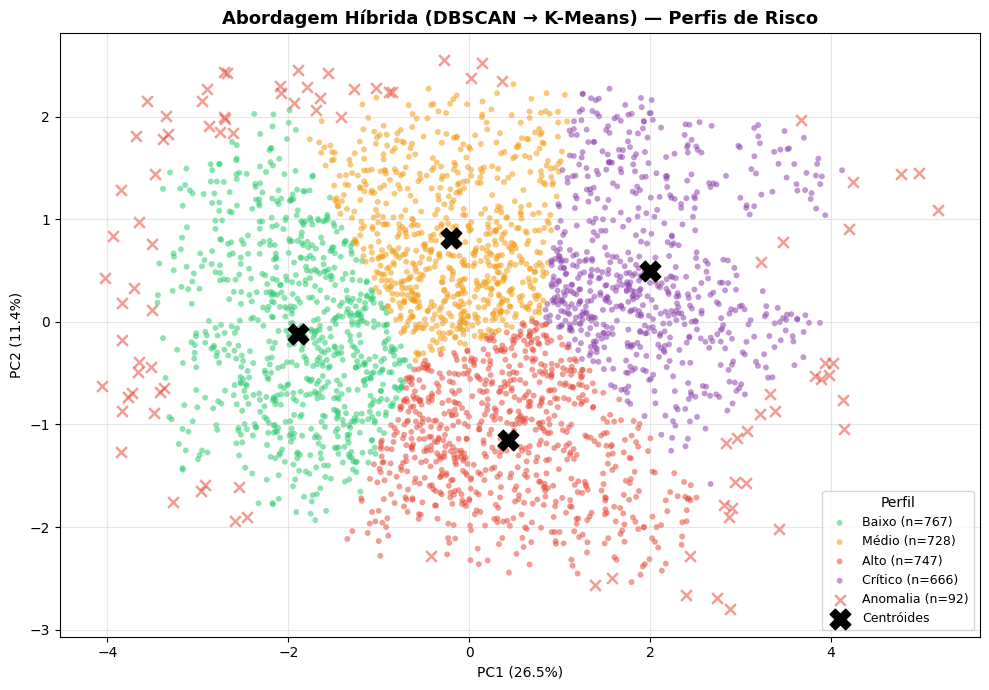

In [40]:
fig, ax = plt.subplots(figsize=(10, 7))
order_plot = ['Baixo','Médio','Alto','Crítico','Anomalia']

for profile in order_plot:
    mask = df['Hybrid_Profile'] == profile
    if mask.sum() == 0: continue
    kw = dict(c=RISK_COLORS[profile],
              label=f'{profile} (n={mask.sum()})',
              alpha=0.55)
    if profile == 'Anomalia':
        ax.scatter(df.loc[mask,'PC1'], df.loc[mask,'PC2'],
                   marker='x', s=60, linewidths=1.8, **kw)
    else:
        ax.scatter(df.loc[mask,'PC1'], df.loc[mask,'PC2'],
                   s=18, edgecolors='none', **kw)

ax.scatter(km_hyb.cluster_centers_[:,0], km_hyb.cluster_centers_[:,1],
           c='black', marker='X', s=220, zorder=5, label='Centróides')

ax.set_title('Abordagem Híbrida (DBSCAN → K-Means) — Perfis de Risco',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1%})')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%})')
ax.legend(title='Perfil', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hybrid_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📏 FASE 5 — Evaluation
### 5.1 Métricas Internas (Silhouette Score e Davies-Bouldin Index)

In [41]:
def metricas_internas(X, labels, nome):
    mask = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return {'Modelo': nome, 'Silhouette ↑': None, 'DBI ↓': None, 'n_clusters': 0}
    return {
        'Modelo':       nome,
        'Silhouette ↑': round(silhouette_score(X[mask], labels[mask]), 4),
        'DBI ↓':        round(davies_bouldin_score(X[mask], labels[mask]), 4),
        'n_clusters':   len(set(labels[mask]))
    }

profile_to_int = {'Baixo':0,'Médio':1,'Alto':2,'Crítico':3,'Anomalia':-1}
hybrid_int     = np.array([profile_to_int[p] for p in df['Hybrid_Profile']])
kmeans_int     = np.array([profile_to_int[p] for p in df['KMeans_Profile']])

results_int = pd.DataFrame([
    metricas_internas(X_pca, km_labels,  'K-Means'),
    metricas_internas(X_pca, db_labels,  'DBSCAN'),
    metricas_internas(X_pca, hybrid_int, 'Híbrido'),
])

print('=== MÉTRICAS INTERNAS ===')
display(results_int)
print('\nLegenda:')
print('  Silhouette ↑: [-1, 1] → mais próximo de 1 = clusters coesos e bem separados')
print('  DBI ↓:        [0, ∞)  → mais próximo de 0 = clusters melhor separados')

=== MÉTRICAS INTERNAS ===


,Modelo,Silhouette ↑,DBI ↓,n_clusters
0,K-Means,0.3474,0.8857,4
1,DBSCAN,0.2687,0.6788,3
2,Híbrido,0.3522,0.8827,4



Legenda:
  Silhouette ↑: [-1, 1] → mais próximo de 1 = clusters coesos e bem separados
  DBI ↓:        [0, ∞)  → mais próximo de 0 = clusters melhor separados


### 5.2 Métricas Externas — Proxy de Ground Truth

> O dataset não possui rótulo de severidade direto. Usamos `Security Vulnerability Type` como ground truth ordinal:
> `Weak Passwords (0)` → `Unpatched Software (1)` → `Social Engineering (2)` → `Zero-day (3)`

In [42]:
vuln_to_level = {
    'Weak Passwords': 0, 'Unpatched Software': 1,
    'Social Engineering': 2, 'Zero-day': 3
}
y_true = df['Security Vulnerability Type'].map(vuln_to_level).values

def ari_score(pred_labels, y_true, nome):
    mask = pred_labels != -1
    ari  = adjusted_rand_score(y_true[mask], pred_labels[mask])
    # Alinha por Hungarian para F1
    p, t = pred_labels[mask], y_true[mask]
    n    = max(p.max()+1, t.max()+1)
    cm   = np.zeros((n, n), dtype=int)
    for pi, ti in zip(p, t):
        if 0 <= pi < n and 0 <= ti < n:
            cm[ti, pi] += 1
    r, c   = linear_sum_assignment(-cm)
    mapping = {c[i]: r[i] for i in range(len(r))}
    p_map   = np.array([mapping.get(x, x) for x in p])
    f1      = f1_score(t, p_map, average='weighted', zero_division=0)
    return {'Modelo': nome, 'ARI': round(ari, 4), 'F1-weighted': round(f1, 4)}

results_ext = pd.DataFrame([
    ari_score(km_labels,  y_true, 'K-Means'),
    ari_score(db_labels,  y_true, 'DBSCAN'),
    ari_score(hybrid_int, y_true, 'Híbrido'),
])

print('=== MÉTRICAS EXTERNAS (vs. Vulnerability Ground Truth) ===')
display(results_ext)
print('\nARI: Adjusted Rand Index — mede concordância com o ground truth (1=perfeito, 0=aleatório)')

=== MÉTRICAS EXTERNAS (vs. Vulnerability Ground Truth) ===


,Modelo,ARI,F1-weighted
0,K-Means,0.0473,0.3376
1,DBSCAN,0.0002,0.1223
2,Híbrido,0.0474,0.3429



ARI: Adjusted Rand Index — mede concordância com o ground truth (1=perfeito, 0=aleatório)


### 5.3 Dashboard Comparativo — 3 Modelos lado a lado

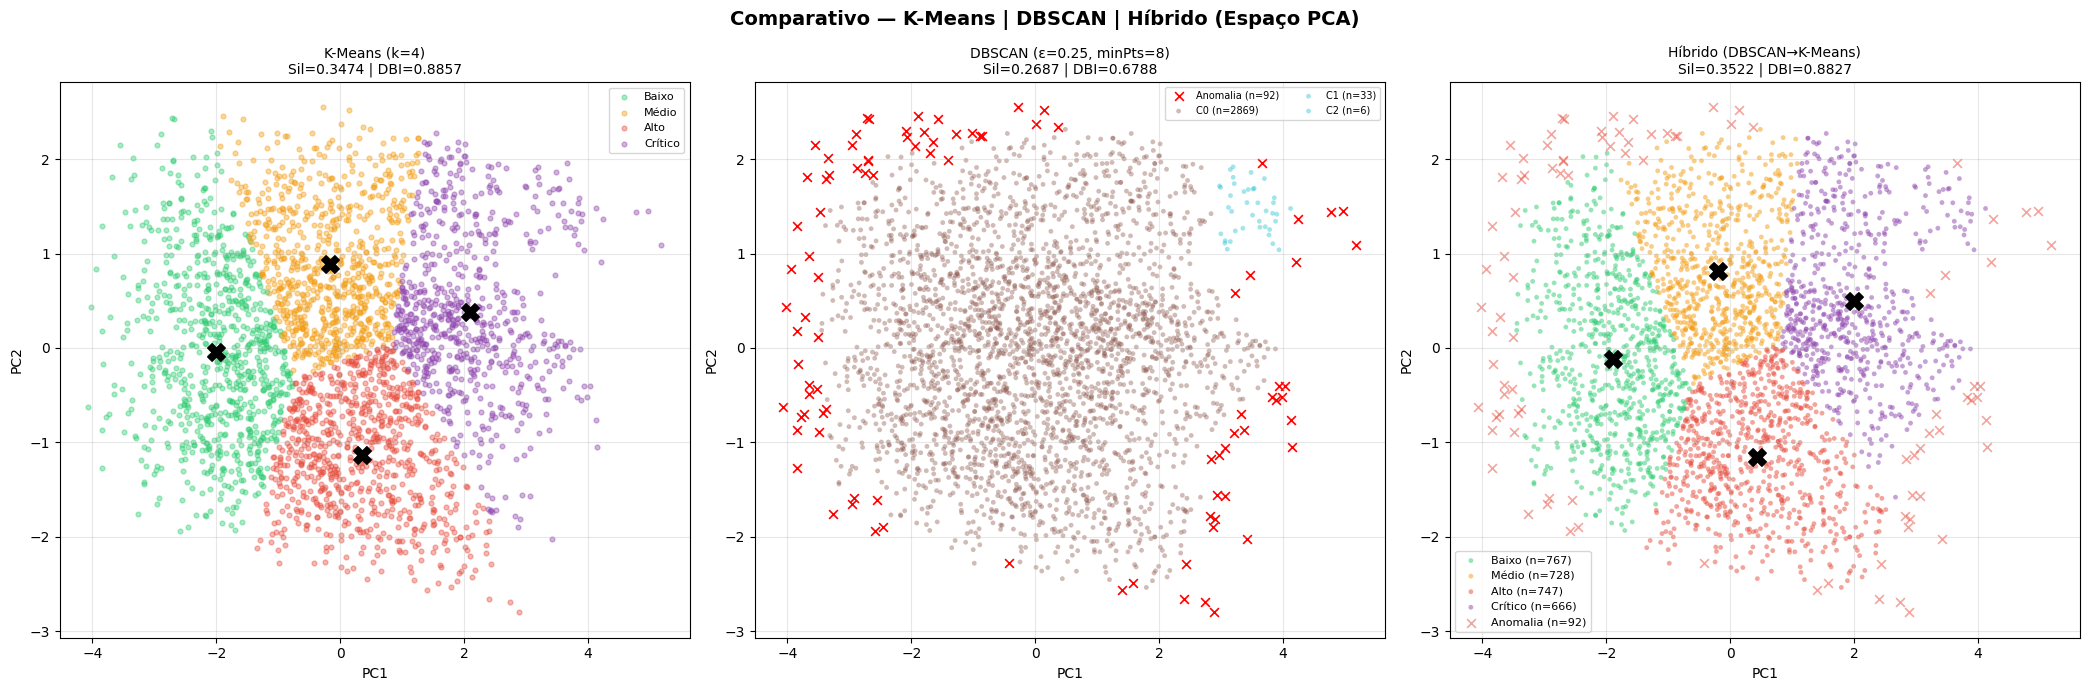

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('Comparativo — K-Means | DBSCAN | Híbrido (Espaço PCA)',
             fontsize=14, fontweight='bold')

sil_km  = results_int.loc[results_int['Modelo']=='K-Means',  'Silhouette ↑'].values[0]
dbi_km  = results_int.loc[results_int['Modelo']=='K-Means',  'DBI ↓'].values[0]
sil_db  = results_int.loc[results_int['Modelo']=='DBSCAN',   'Silhouette ↑'].values[0]
dbi_db  = results_int.loc[results_int['Modelo']=='DBSCAN',   'DBI ↓'].values[0]
sil_hyb = results_int.loc[results_int['Modelo']=='Híbrido',  'Silhouette ↑'].values[0]
dbi_hyb = results_int.loc[results_int['Modelo']=='Híbrido',  'DBI ↓'].values[0]

# K-Means
ax = axes[0]
for p, c in RISK_COLORS.items():
    if p == 'Anomalia': continue
    m = df['KMeans_Profile'] == p
    ax.scatter(df.loc[m,'PC1'], df.loc[m,'PC2'], c=c, alpha=0.4, s=12, label=p)
ax.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s=160, zorder=5)
ax.set_title(f'K-Means (k=4)\nSil={sil_km} | DBI={dbi_km}', fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

# DBSCAN
ax = axes[1]
for i, lbl in enumerate(sorted(set(db_labels))):
    m = db_labels == lbl
    if lbl == -1:
        ax.scatter(X_pca[m,0], X_pca[m,1], c='red', marker='x',
                   s=40, lw=1.2, label=f'Anomalia (n={m.sum()})')
    else:
        ax.scatter(X_pca[m,0], X_pca[m,1], c=[cmap2(i%10)],
                   alpha=0.4, s=12, edgecolors='none', label=f'C{lbl} (n={m.sum()})')
ax.set_title(f'DBSCAN (ε={EPS_OPT}, minPts={MIN_PTS})\nSil={sil_db} | DBI={dbi_db}', fontsize=10)
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

# Híbrido
ax = axes[2]
for p in ['Baixo','Médio','Alto','Crítico','Anomalia']:
    m = df['Hybrid_Profile'] == p
    if m.sum() == 0: continue
    kw = dict(c=RISK_COLORS[p], label=f'{p} (n={m.sum()})', alpha=0.5)
    if p == 'Anomalia':
        ax.scatter(df.loc[m,'PC1'], df.loc[m,'PC2'], marker='x', s=40, lw=1.2, **kw)
    else:
        ax.scatter(df.loc[m,'PC1'], df.loc[m,'PC2'], s=12, edgecolors='none', **kw)
ax.scatter(km_hyb.cluster_centers_[:,0], km_hyb.cluster_centers_[:,1],
           c='black', marker='X', s=160, zorder=5)
ax.set_title(f'Híbrido (DBSCAN→K-Means)\nSil={sil_hyb} | DBI={dbi_hyb}', fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.tight_layout()
plt.savefig('comparativo_final.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🚀 FASE 6 — Deployment
### 6.1 Estatísticas dos Perfis de Risco

In [44]:
order = ['Baixo','Médio','Alto','Crítico','Anomalia']
order = [o for o in order if o in df['Hybrid_Profile'].unique()]

profile_stats = df.groupby('Hybrid_Profile')[NUM_COLS_EDA + ['Severity Score','Risk_Score']]\
                  .agg(['mean','std']).loc[order]
print('=== ESTATÍSTICAS DOS PERFIS (Modelo Híbrido) ===')
display(profile_stats.round(2))

=== ESTATÍSTICAS DOS PERFIS (Modelo Híbrido) ===


Financial Loss (in Million $)        Number of Affected Users  \
                                        mean    std                     mean   
Hybrid_Profile                                                                 
Baixo                                  23.13  16.80                409138.58   
Médio                                  44.34  22.44                499068.04   
Alto                                   61.13  23.52                537744.26   
Crítico                                77.87  16.24                592652.83   
Anomalia                               42.71  36.96                440432.95   

                          Incident Resolution Time (in Hours)         \
                      std                                mean    std   
Hybrid_Profile                                                         
Baixo           270514.80                               25.92  17.67   
Médio           290693.12                               34.02  19.86   
Alto            287767.17                               42.90  19.61   
Crítico         271793.97                               44.74  18.30   
Anomalia        337325.76                               31.87  26.84   

               Severity Score       Risk_Score        
                         mean   std       mean   std  
Hybrid_Profile                                        
Baixo                    3.01  0.79       3.46  1.10  
Médio                    4.60  0.74       6.68  1.73  
Alto                     5.89  1.03       6.24  1.60  
Crítico                  6.92  0.88      10.53  2.52  
Anomalia                 4.31  3.39       6.41  5.51

### 6.2 Heatmap de Características Médias por Perfil

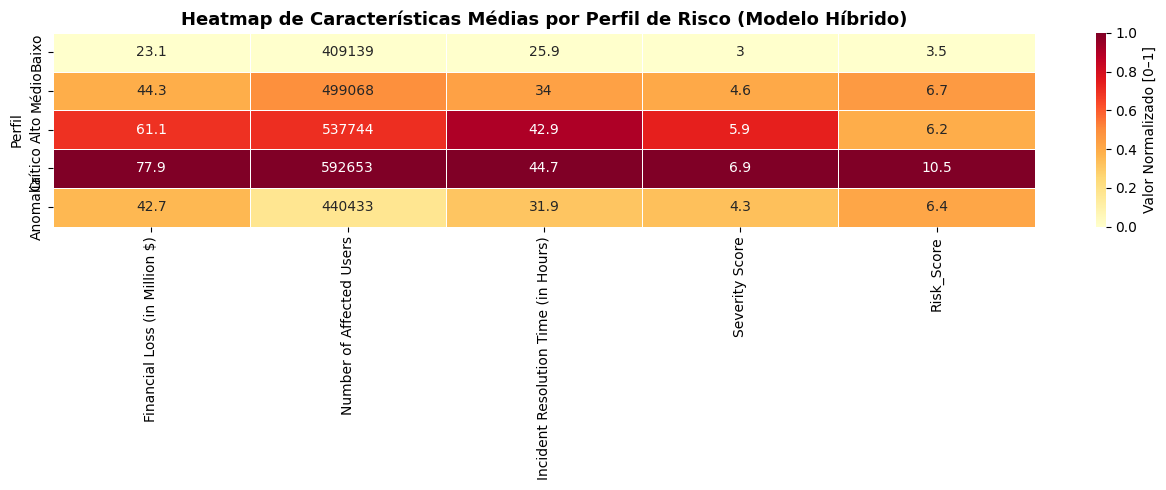

In [45]:
hm_cols = NUM_COLS_EDA + ['Severity Score','Risk_Score']
hm_data = df.groupby('Hybrid_Profile')[hm_cols].mean().loc[order]
hm_norm = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min() + 1e-9)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(hm_norm, annot=hm_data.round(1), fmt='g',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Valor Normalizado [0–1]'})
ax.set_title('Heatmap de Características Médias por Perfil de Risco (Modelo Híbrido)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Perfil'); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('heatmap_perfis.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Composição dos Perfis por Tipo de Ataque e Vulnerabilidade

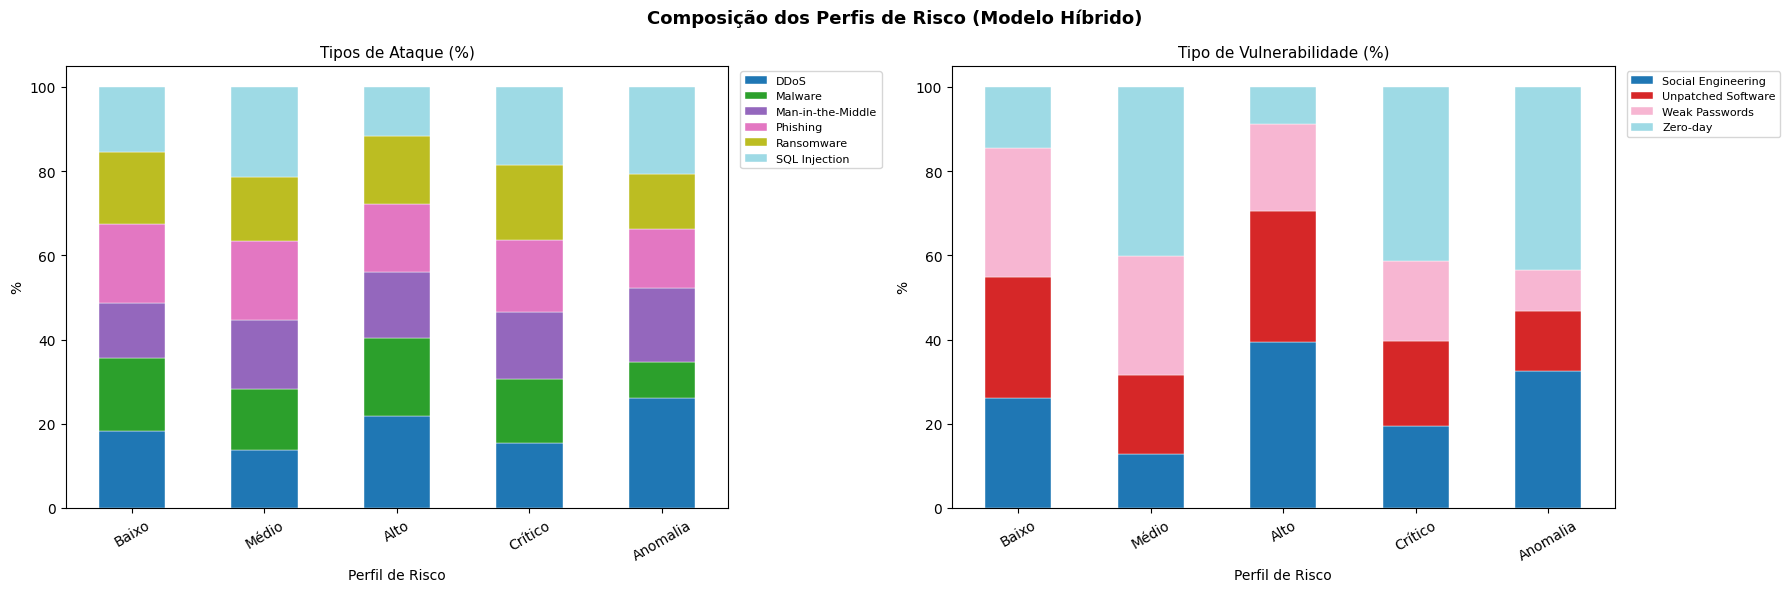

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Composição dos Perfis de Risco (Modelo Híbrido)',
             fontsize=13, fontweight='bold')

valid = df[df['Hybrid_Profile'].isin(order)]

for ax, col, title in zip(
    axes,
    ['Attack Type', 'Security Vulnerability Type'],
    ['Tipos de Ataque (%)', 'Tipo de Vulnerabilidade (%)']
):
    ct = pd.crosstab(valid['Hybrid_Profile'], valid[col], normalize='index') * 100
    ct = ct.loc[[o for o in order if o in ct.index]]
    ct.plot(kind='bar', stacked=True, ax=ax, cmap='tab20',
            edgecolor='white', linewidth=0.3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Perfil de Risco'); ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('composicao_perfis.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Evolução Temporal dos Perfis (2015–2024)

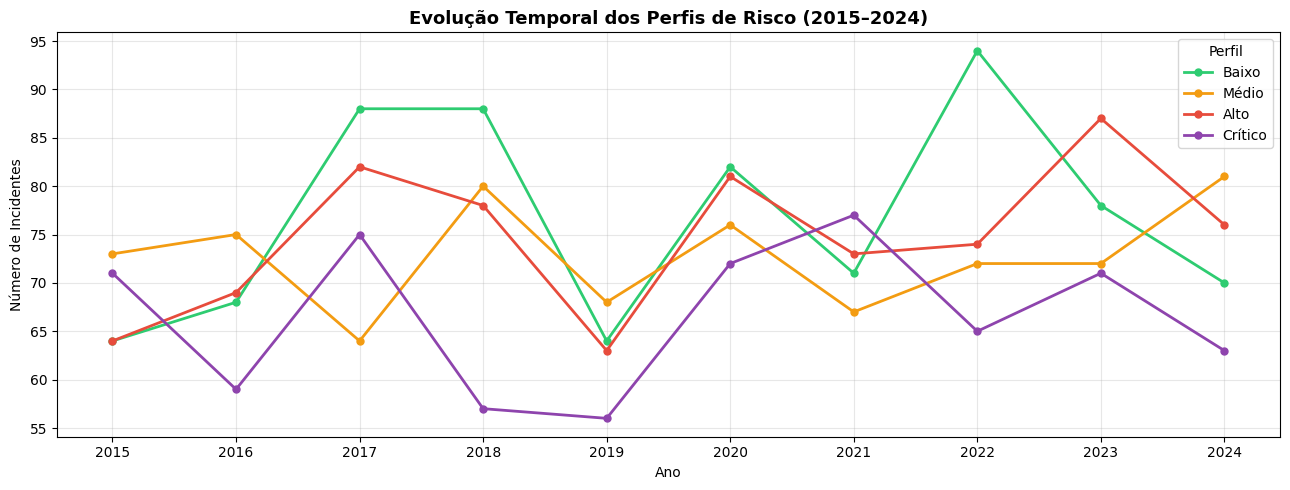

In [47]:
timeline = df[df['Hybrid_Profile'].isin(['Baixo','Médio','Alto','Crítico'])]\
             .groupby(['Year','Hybrid_Profile']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
for profile in ['Baixo','Médio','Alto','Crítico']:
    if profile in timeline.columns:
        ax.plot(timeline.index, timeline[profile], marker='o',
                linewidth=2, markersize=5,
                color=RISK_COLORS[profile], label=profile)

ax.set_title('Evolução Temporal dos Perfis de Risco (2015–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano'); ax.set_ylabel('Número de Incidentes')
ax.set_xticks(timeline.index); ax.grid(alpha=0.3)
ax.legend(title='Perfil')
plt.tight_layout()
plt.savefig('timeline_perfis.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Função de Classificação de Novos Incidentes

In [48]:
# Valores de referência do treino para normalização do Severity Score
_loss_min = df_raw['Financial Loss (in Million $)'].min()
_loss_max = df_raw['Financial Loss (in Million $)'].max()
_mtr_min  = df_raw['Incident Resolution Time (in Hours)'].min()
_mtr_max  = df_raw['Incident Resolution Time (in Hours)'].max()
_usr_min  = df_raw['Number of Affected Users'].min()
_usr_max  = df_raw['Number of Affected Users'].max()

_source_weight = {'Nation-state': 1.5, 'Unknown': 1.2,
                  'Insider': 1.0, 'Hacker Group': 0.9}
_vuln_weight   = {'Zero-day': 1.5, 'Social Engineering': 1.2,
                  'Unpatched Software': 1.0, 'Weak Passwords': 0.8}

# Valores válidos para referência
VALID_ATTACK_TYPES  = ['DDoS','Phishing','SQL Injection','Ransomware',
                        'Malware','Man-in-the-Middle']
VALID_INDUSTRIES    = ['IT','Banking','Healthcare','Retail',
                        'Education','Telecommunications','Government']
VALID_SOURCES       = ['Nation-state','Unknown','Insider','Hacker Group']
VALID_VULNS         = ['Zero-day','Social Engineering',
                        'Unpatched Software','Weak Passwords']
VALID_DEFENSES      = ['Antivirus','VPN','Encryption','Firewall','AI-based Detection']

# Modelo de vizinhança usado para detecção de anomalias
nbrs = NearestNeighbors(n_neighbors=MIN_PTS, metric='cosine')
nbrs.fit(X_pca)

def classificar_incidente(
    financial_loss: float,
    resolution_time: float,
    affected_users: int,
    attack_type: str       = 'Phishing',
    target_industry: str   = 'Banking',
    attack_source: str     = 'Hacker Group',
    security_vuln: str     = 'Unpatched Software',
    defense_mechanism: str = 'Firewall'
) -> dict:
    """
    Classifica um novo incidente usando o modelo híbrido treinado.

    Parâmetros válidos:
    - attack_type:       DDoS | Phishing | SQL Injection | Ransomware | Malware | Man-in-the-Middle
    - target_industry:   IT | Banking | Healthcare | Retail | Education | Telecommunications | Government
    - attack_source:     Nation-state | Unknown | Insider | Hacker Group
    - security_vuln:     Zero-day | Social Engineering | Unpatched Software | Weak Passwords
    - defense_mechanism: Antivirus | VPN | Encryption | Firewall | AI-based Detection
    """
    # Recria Severity Score e Risk_Score
    loss_n   = (financial_loss  - _loss_min) / (_loss_max - _loss_min + 1e-9)
    mtr_n    = (resolution_time - _mtr_min)  / (_mtr_max  - _mtr_min  + 1e-9)
    usr_n    = (affected_users  - _usr_min)  / (_usr_max  - _usr_min  + 1e-9)
    severity = (loss_n*0.50 + mtr_n*0.30 + usr_n*0.20) * 10
    sw       = _source_weight.get(attack_source, 1.0)
    vw       = _vuln_weight.get(security_vuln, 1.0)
    risk     = severity * sw * vw

    def encode(col, val):
        return encoders[col].transform([val])[0] if val in encoders[col].classes_ else 0

    row = {
        'Financial Loss (in Million $)':        financial_loss,
        'Incident Resolution Time (in Hours)':  resolution_time,
        'Number of Affected Users':             affected_users,
        'Severity Score':                        severity,
        'Risk_Score':                            risk,
        'Attack Type_enc':                       encode('Attack Type', attack_type),
        'Target Industry_enc':                   encode('Target Industry', target_industry),
        'Attack Source_enc':                     encode('Attack Source', attack_source),
        'Security Vulnerability Type_enc':       encode('Security Vulnerability Type', security_vuln),
        'Defense Mechanism Used_enc':            encode('Defense Mechanism Used', defense_mechanism),
    }

    X_new     = scaler.transform([[row[c] for c in FEATURE_COLS]])
    X_new_pca = pca.transform(X_new)

    # Verificação de anomalia: distância ao minPts-ésimo vizinho > ε
    dist_nn, _ = nbrs.kneighbors(X_new_pca)
    is_anomaly = dist_nn[0, -1] > EPS_OPT

    recomendacoes = {
        'Baixo':    '🟢 Monitoramento padrão. Resolução no próximo ciclo de manutenção.',
        'Médio':    '🟡 Acompanhamento ativo. Escalar para analista sênior se não resolvido em 24h.',
        'Alto':     '🟠 Resposta imediata. Acionar equipe IR. Isolar ativo afetado.',
        'Crítico':  '🔴 INCIDENTE CRÍTICO — Acionar CISO. Protocolo de crise ativado.',
        'Anomalia': '🚨 EVENTO SEM PRECEDENTE — Investigação forense prioritária. Zero-day potencial.',
    }

    if is_anomaly:
        perfil = 'Anomalia'
    else:
        cluster = km_hyb.predict(X_new_pca)[0]
        perfil  = label_hyb[cluster]

    return {
        'perfil':         perfil,
        'severity_score': round(severity, 2),
        'risk_score':     round(risk, 2),
        'recomendação':   recomendacoes[perfil]
    }


# Exemplos de uso
casos = [
    dict(financial_loss=2.1,  resolution_time=5,  affected_users=1500,
         attack_type='Phishing',    target_industry='Education',
         attack_source='Hacker Group', security_vuln='Weak Passwords',
         defense_mechanism='Antivirus'),

    dict(financial_loss=35.0, resolution_time=28, affected_users=200000,
         attack_type='DDoS',        target_industry='Banking',
         attack_source='Unknown',      security_vuln='Unpatched Software',
         defense_mechanism='Firewall'),

    dict(financial_loss=72.0, resolution_time=55, affected_users=650000,
         attack_type='Ransomware',  target_industry='Healthcare',
         attack_source='Nation-state', security_vuln='Social Engineering',
         defense_mechanism='Encryption'),

    dict(financial_loss=98.0, resolution_time=70, affected_users=950000,
         attack_type='SQL Injection', target_industry='Government',
         attack_source='Nation-state', security_vuln='Zero-day',
         defense_mechanism='AI-based Detection'),
]

print('=== CLASSIFICAÇÃO DE NOVOS INCIDENTES (Modelo Híbrido) ===')
for i, caso in enumerate(casos, 1):
    r = classificar_incidente(**caso)
    print(f'\nIncidente {i}:')
    print(f'  Loss: US$ {caso["financial_loss"]}M | MTTR: {caso["resolution_time"]}h'
          f' | Usuários: {caso["affected_users"]:,}')
    print(f'  Tipo: {caso["attack_type"]} | Fonte: {caso["attack_source"]}'
          f' | Vuln: {caso["security_vuln"]}')
    print(f'  → Perfil:   {r["perfil"]}')
    print(f'  → Severity: {r["severity_score"]} | Risk: {r["risk_score"]}')
    print(f'  → {r["recomendação"]}')

=== CLASSIFICAÇÃO DE NOVOS INCIDENTES (Modelo Híbrido) ===

Incidente 1:
  Loss: US$ 2.1M | MTTR: 5h | Usuários: 1,500
  Tipo: Phishing | Fonte: Hacker Group | Vuln: Weak Passwords
  → Perfil:   Baixo
  → Severity: 0.25 | Risk: 0.18
  → 🟢 Monitoramento padrão. Resolução no próximo ciclo de manutenção.

Incidente 2:
  Loss: US$ 35.0M | MTTR: 28h | Usuários: 200,000
  Tipo: DDoS | Fonte: Unknown | Vuln: Unpatched Software
  → Perfil:   Baixo
  → Severity: 3.27 | Risk: 3.93
  → 🟢 Monitoramento padrão. Resolução no próximo ciclo de manutenção.

Incidente 3:
  Loss: US$ 72.0M | MTTR: 55h | Usuários: 650,000
  Tipo: Ransomware | Fonte: Nation-state | Vuln: Social Engineering
  → Perfil:   Crítico
  → Severity: 7.18 | Risk: 12.92
  → 🔴 INCIDENTE CRÍTICO — Acionar CISO. Protocolo de crise ativado.

Incidente 4:
  Loss: US$ 98.0M | MTTR: 70h | Usuários: 950,000
  Tipo: SQL Injection | Fonte: Nation-state | Vuln: Zero-day
  → Perfil:   Crítico
  → Severity: 9.72 | Risk: 21.86
  → 🔴 INCIDENTE CRÍ

### 6.6 Resumo Final dos Modelos

In [49]:
resumo = pd.DataFrame({
    'Modelo':     ['K-Means', 'DBSCAN', 'Híbrido (DBSCAN → K-Means)'],
    'Parâmetros': [f'k={K_OPT}, init=k-means++',
                   f'ε={EPS_OPT}, minPts={MIN_PTS}',
                   f'ε={EPS_OPT} + k=4'],
    'Clusters':   [K_OPT, n_clusters_db, 4],
    'Anomalias':  [0, n_noise, int(mask_anomaly.sum())],
    'Vantagem principal': [
        'Perfis coesos e interpretáveis; escalável',
        'Detecta zero-days explicitamente; não exige k',
        'Combina perfis estruturados com detecção de anomalias'
    ],
    'Limitação principal': [
        'Sensível a outliers; assume clusters esféricos',
        'Não nomeia perfis; sensível a ε e minPts',
        'Depende da qualidade de ε e k'
    ]
})
display(resumo)

imagens = [
    'eda_numericas.png', 'eda_categoricas.png', 'eda_impacto_financeiro.png',
    'pca_analysis.png', 'kmeans_selecao_k.png', 'kmeans_clusters.png',
    'dbscan_kdist.png', 'dbscan_clusters.png', 'hybrid_clusters.png',
    'comparativo_final.png', 'heatmap_perfis.png',
    'composicao_perfis.png', 'timeline_perfis.png'
]
print(f'\n✅ Pipeline CRISP-DM concluído — {len(imagens)} figuras geradas:')
for f in imagens:
    print(f'  📊 {f}')

,Modelo,Parâmetros,Clusters,Anomalias,Vantagem principal,Limitação principal
0,K-Means,"k=4, init=k-means++",4,0,Perfis coesos e interpretáveis; escalável,Sensível a outliers; assume clusters esféricos
1,DBSCAN,"ε=0.25, minPts=8",3,92,Detecta zero-days explicitamente; não exige k,Não nomeia perfis; sensível a ε e minPts
2,Híbrido (DBSCAN → K-Means),ε=0.25 + k=4,4,92,Combina perfis estruturados com detecção de an...,Depende da qualidade de ε e k



✅ Pipeline CRISP-DM concluído — 13 figuras geradas:
  📊 eda_numericas.png
  📊 eda_categoricas.png
  📊 eda_impacto_financeiro.png
  📊 pca_analysis.png
  📊 kmeans_selecao_k.png
  📊 kmeans_clusters.png
  📊 dbscan_kdist.png
  📊 dbscan_clusters.png
  📊 hybrid_clusters.png
  📊 comparativo_final.png
  📊 heatmap_perfis.png
  📊 composicao_perfis.png
  📊 timeline_perfis.png
